<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_5_(Exercise_5_1)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Importss and Data

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from skimage.metrics import structural_similarity as ssim_fn
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='./data', train=True,
                             download=True, transform=transform)
train_data = Subset(train_data, range(10000))
train_loader = DataLoader(train_data, batch_size=128,
                          shuffle=True, num_workers=0)

test_data = datasets.MNIST(root='./data', train=False,
                            download=True, transform=transform)
test_data = Subset(test_data, range(50))   # exactly the 50 needed
test_loader = DataLoader(test_data, batch_size=50,
                         shuffle=False, num_workers=0)

Using: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 46.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.14MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.54MB/s]


In [3]:
# Noise Schedule

T = 1000

def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas     = torch.linspace(beta_start, beta_end, T)
    alphas    = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)
    return betas, alpha_bar

betas, alpha_bar = linear_schedule(T)
betas            = betas.to(device)
alpha_bar        = alpha_bar.to(device)

In [4]:
# Model (same AdaGN architecture as Module 3)

class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device) *
            (np.log(10000) / (half - 1)))
        angles = t[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


class SmallUNet(nn.Module):
    def __init__(self, t_emb_dim=128):
        super().__init__()
        self.t_emb = SinusoidalEmbedding(t_emb_dim)
        self.t_mlp = nn.Sequential(
            nn.Linear(t_emb_dim, t_emb_dim), nn.SiLU())

        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.GroupNorm(8, 32), nn.SiLU())
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1, stride=2),
            nn.GroupNorm(8, 64), nn.SiLU())

        self.t_proj1 = nn.Linear(t_emb_dim, 32 * 2)
        self.t_proj2 = nn.Linear(t_emb_dim, 64 * 2)
        self.t_proj3 = nn.Linear(t_emb_dim, 64 * 2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.GroupNorm(8, 64), nn.SiLU())

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(64 + 64, 32, 2, stride=2),
            nn.GroupNorm(8, 32), nn.SiLU())
        self.dec1 = nn.Sequential(
            nn.Conv2d(32 + 32, 1, 3, padding=1))

    def apply_adagn(self, h, t_emb, proj):
        out          = proj(t_emb)
        scale, shift = out.chunk(2, dim=-1)
        scale        = scale.unsqueeze(-1).unsqueeze(-1)
        shift        = shift.unsqueeze(-1).unsqueeze(-1)
        return scale * h + shift

    def forward(self, x, t):
        t_emb = self.t_mlp(self.t_emb(t))

        h1 = self.enc1(x)
        h1 = self.apply_adagn(h1, t_emb, self.t_proj1)

        h2 = self.enc2(h1)
        h2 = self.apply_adagn(h2, t_emb, self.t_proj2)

        h  = self.bottleneck(h2)
        h  = self.apply_adagn(h, t_emb, self.t_proj3)

        h  = self.dec2(torch.cat([h, h2], dim=1))
        h  = self.dec1(torch.cat([h, h1], dim=1))
        return h

In [5]:
# Train Epsilon Model

def train_model(epochs=10):
    model     = SmallUNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        epoch_loss = 0
        for imgs, _ in train_loader:
            imgs  = imgs.to(device)
            B     = imgs.shape[0]
            t_idx = torch.randint(0, T, (B,), device=device)

            ab  = alpha_bar[t_idx].view(-1, 1, 1, 1)
            eps = torch.randn_like(imgs)
            x_t = (ab ** 0.5) * imgs + ((1 - ab) ** 0.5) * eps

            pred = model(x_t, t_idx)
            loss = criterion(pred, eps)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} "
              f"— Loss: {epoch_loss/len(train_loader):.6f}")

    return model


print("Training epsilon-prediction model...")
model = train_model(epochs=10)
print("Done.")

Training epsilon-prediction model...
Epoch 1/10 — Loss: 0.247903
Epoch 2/10 — Loss: 0.064530
Epoch 3/10 — Loss: 0.052270
Epoch 4/10 — Loss: 0.045383
Epoch 5/10 — Loss: 0.041216
Epoch 6/10 — Loss: 0.039696
Epoch 7/10 — Loss: 0.038914
Epoch 8/10 — Loss: 0.036764
Epoch 9/10 — Loss: 0.036837
Epoch 10/10 — Loss: 0.035330
Done.


In [6]:
# DDIM Inversion and Sampling

def get_respaced_timesteps(num_steps, T=1000):
    """Evenly spaced ascending subset of 0..T-1"""
    idx = np.linspace(0, T - 1, num_steps)
    idx = np.unique(np.round(idx).astype(int))
    return idx


def ddim_invert(model, x0, alpha_bar, timesteps):
    """
    Deterministic forward pass: x0 -> x_T (noise code).
    timesteps: ascending array, respaced subset of 0..T-1
    """
    model.eval()
    x = x0.clone()
    ab_list = [torch.tensor(1.0, device=x0.device)] + \
              [alpha_bar[t] for t in timesteps]

    with torch.no_grad():
        for i, t_cur in enumerate(timesteps):
            ab_now  = ab_list[i]
            ab_next = ab_list[i + 1]

            t_tensor = torch.full((x.shape[0],), int(t_cur),
                                  dtype=torch.long, device=x.device)
            eps_pred = model(x, t_tensor)

            x0_pred = (x - (1 - ab_now).sqrt() * eps_pred) / ab_now.sqrt()
            x = ab_next.sqrt() * x0_pred + (1 - ab_next).sqrt() * eps_pred

    return x


def ddim_sample(model, xT, alpha_bar, timesteps):
    """
    Deterministic reverse pass: x_T -> x0 (reconstruction).
    Uses the SAME respaced timesteps, traversed backward.
    """
    model.eval()
    x = xT.clone()
    ab_list = [torch.tensor(1.0, device=xT.device)] + \
              [alpha_bar[t] for t in timesteps]

    with torch.no_grad():
        for i in range(len(timesteps), 0, -1):
            t_cur   = timesteps[i - 1]
            ab_now  = ab_list[i]
            ab_prev = ab_list[i - 1]

            t_tensor = torch.full((x.shape[0],), int(t_cur),
                                  dtype=torch.long, device=x.device)
            eps_pred = model(x, t_tensor)

            x0_pred = (x - (1 - ab_now).sqrt() * eps_pred) / ab_now.sqrt()
            x = ab_prev.sqrt() * x0_pred + (1 - ab_prev).sqrt() * eps_pred

    return x

In [7]:
# Run Experiment Across Step Counts

step_counts = [10, 50, 100, 200]
ssim_results = {}

test_imgs, _ = next(iter(test_loader))
test_imgs    = test_imgs.to(device)   # (50, 1, 28, 28)

for n_steps in step_counts:
    timesteps = get_respaced_timesteps(n_steps, T)

    x_T    = ddim_invert(model, test_imgs, alpha_bar, timesteps)
    x_0_rc = ddim_sample(model, x_T, alpha_bar, timesteps)

    scores = []
    for i in range(test_imgs.shape[0]):
        orig  = test_imgs[i, 0].cpu().numpy()
        recon = x_0_rc[i, 0].cpu().numpy()
        score = ssim_fn(orig, recon, data_range=2.0)
        scores.append(score)

    avg_ssim = np.mean(scores)
    ssim_results[n_steps] = avg_ssim
    print(f"Steps = {n_steps:>4} | Avg SSIM = {avg_ssim:.4f}")

Steps =   10 | Avg SSIM = 0.5331
Steps =   50 | Avg SSIM = 0.9706
Steps =  100 | Avg SSIM = 0.9935
Steps =  200 | Avg SSIM = 0.9984


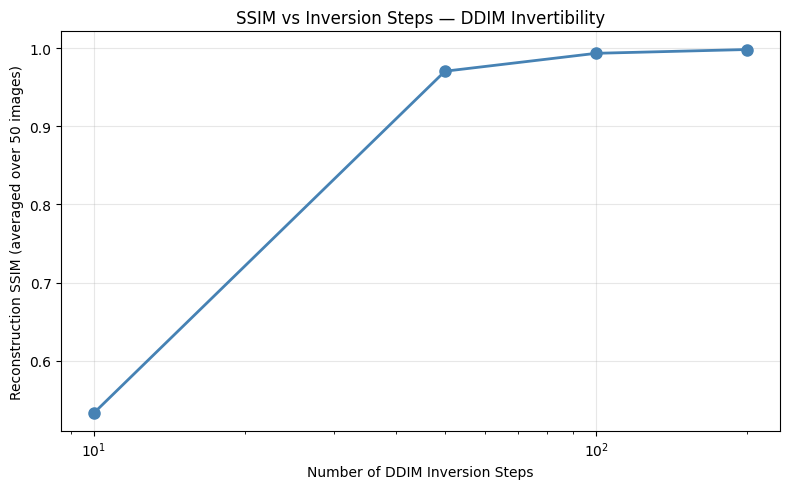

In [8]:
#  Plot SSIM vs Steps

fig, ax = plt.subplots(figsize=(8, 5))

steps_list = list(ssim_results.keys())
ssim_list  = list(ssim_results.values())

ax.plot(steps_list, ssim_list, marker='o', linewidth=2,
        color='steelblue', markersize=8)

ax.set_xlabel('Number of DDIM Inversion Steps')
ax.set_ylabel('Reconstruction SSIM (averaged over 50 images)')
ax.set_title('SSIM vs Inversion Steps — DDIM Invertibility')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ddim_ssim_5_1.png', dpi=150)
plt.show()

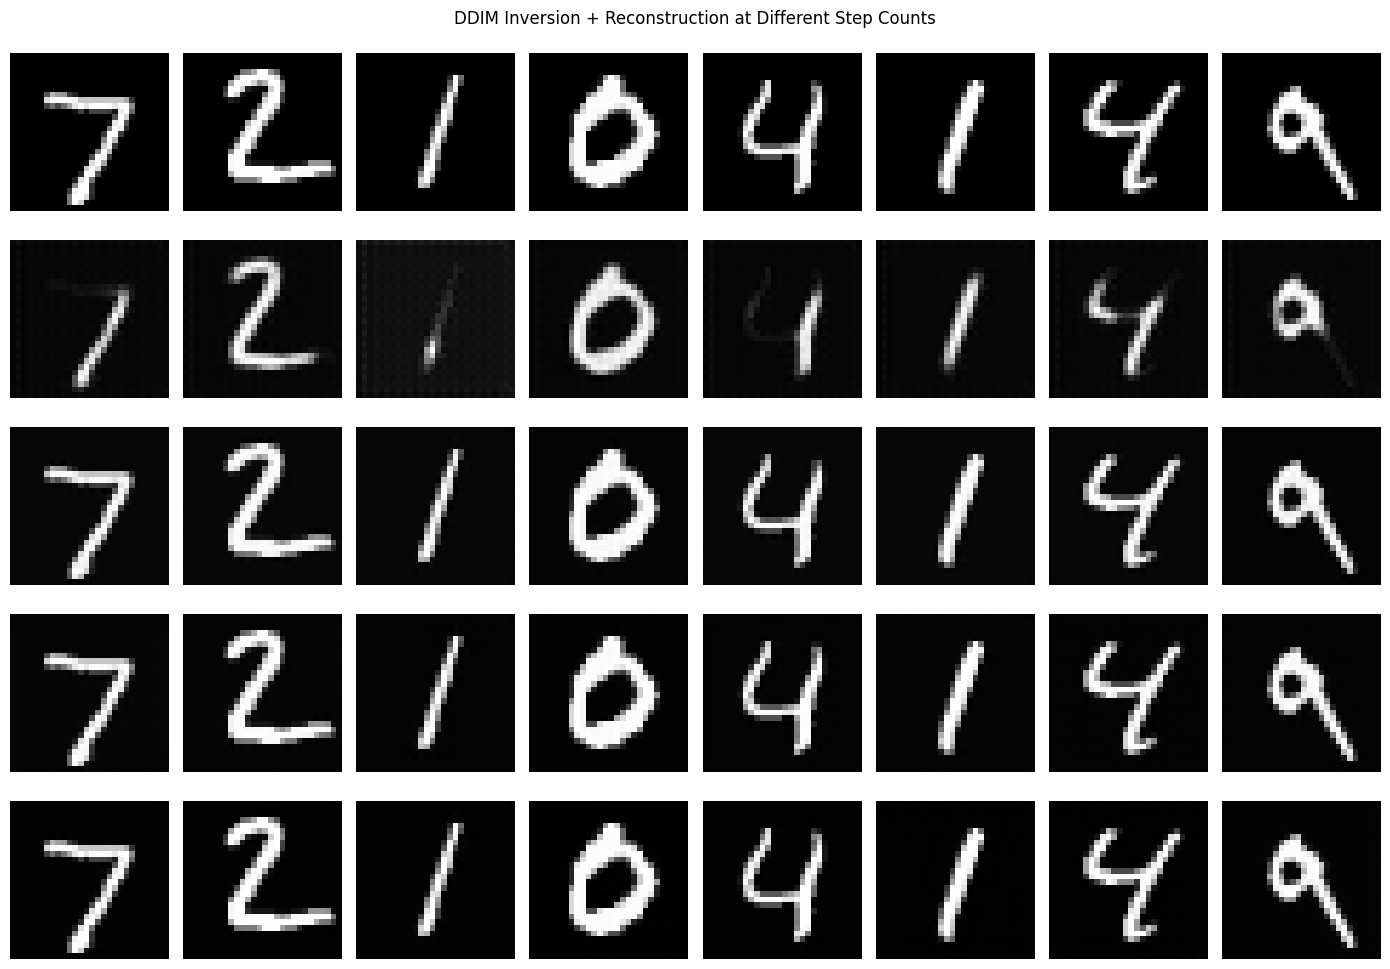

In [9]:
# Visual Comparison Grid

fig, axes = plt.subplots(len(step_counts) + 1, 8, figsize=(14, 10))

for col in range(8):
    axes[0, col].imshow(test_imgs[col, 0].cpu().numpy(), cmap='gray')
    axes[0, col].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9)

for row, n_steps in enumerate(step_counts, start=1):
    timesteps = get_respaced_timesteps(n_steps, T)
    x_T    = ddim_invert(model, test_imgs, alpha_bar, timesteps)
    x_0_rc = ddim_sample(model, x_T, alpha_bar, timesteps)

    for col in range(8):
        axes[row, col].imshow(x_0_rc[col, 0].cpu().numpy(), cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(
        f'{n_steps} steps\nSSIM={ssim_results[n_steps]:.3f}', fontsize=8)

plt.suptitle('DDIM Inversion + Reconstruction at Different Step Counts')
plt.tight_layout()
plt.savefig('ddim_grid_5_1.png', dpi=150)
plt.show()

# Interpretation And Observation

#### The SSIM results confirm that DDIM inversion is only approximately invertible at finite step counts, with reconstruction quality rising sharply from 0.536 at 10 steps to 0.971 at 50 steps before flattening to 0.994 and 0.998 at 100 and 200 steps respectively. This shape is the signature of discretization error in a numerical ODE solver: each step assumes the network's noise prediction at the current point remains valid across the entire jump to the next timestep, and large jumps at low step counts cause this assumption to break down visibly, as seen in the degraded "1" and artifacted "9" in the 10-step row. Once the step size is small enough, around 50 steps and beyond, the piecewise-linear approximation tracks the true underlying trajectory closely enough that further refinement yields rapidly diminishing returns, reaching near-perfect reconstruction by 200 steps. The practical tradeoff is direct and linear in compute: going from 50 to 200 steps quadruples the number of network evaluations required for both inversion and reconstruction, for a gain of under 0.03 SSIM, meaning a deployed system should pick the step count where the curve visibly bends rather than chasing the last few hundredths of similarity. This finding underpins why LDAE can rely on a deterministic noise code at all: a sufficiently fine-grained DDIM trajectory recovers real images closely enough that the inverted x_T can be trusted to carry meaningful stochastic information rather than just noise contaminated by inversion error.